In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split

In [2]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### Classification of standard and luxury cars based on the third quartile price and a decision tree, along with its visualization

In [ ]:
# LOGISTIC REGRESSION
# median_price = df['sellingprice'].median()
median_price = df.groupby('make')['sellingprice'].quantile(0.75)
df['median_make'] = df['make'].map(median_price)
df['is_high_value'] = (df['sellingprice'] > df['median_make']).astype(int)
df['car_age'] = 2026 - df['year']

print(df['is_high_value'].value_counts())

X_log = df[['year', 'condition', 'odometer']].dropna()
y_log = df.loc[X_log.index, 'is_high_value']

X_log = sm.add_constant(X_log)

logit_model = sm.Logit(y_log, X_log).fit()
print(logit_model.summary())

predictions_prob = logit_model.predict(X_log)
predictions = (predictions_prob > 0.2599).astype(int) # Threshold
print(classification_report(y_log, predictions))

"""Accuracy: What percentage of all cars did the model classify correctly?
Precision: If the model classified a car as "budget/luxury," how often was it correct?
Recall: How many of the truly luxury cars did the model manage to identify in the dataset?
Specificity: How often did we make a mistake by classifying a cheap car as expensive?"""

is_high_value
0    420354
1    138479
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.448318
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          is_high_value   No. Observations:               546988
Model:                          Logit   Df Residuals:                   546984
Method:                           MLE   Df Model:                            3
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.2053
Time:                        14:52:02   Log-Likelihood:            -2.4522e+05
converged:                       True   LL-Null:                   -3.0859e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -359.4468      4.682    -76.769 

'Accuracy: What percentage of all cars did the model classify correctly?\nPrecision: If the model classified a car as "budget/luxury," how often was it correct?\nRecall: How many of the truly luxury cars did the model manage to identify in the dataset?\nSpecificity: How often did we make a mistake by classifying a cheap car as expensive?'

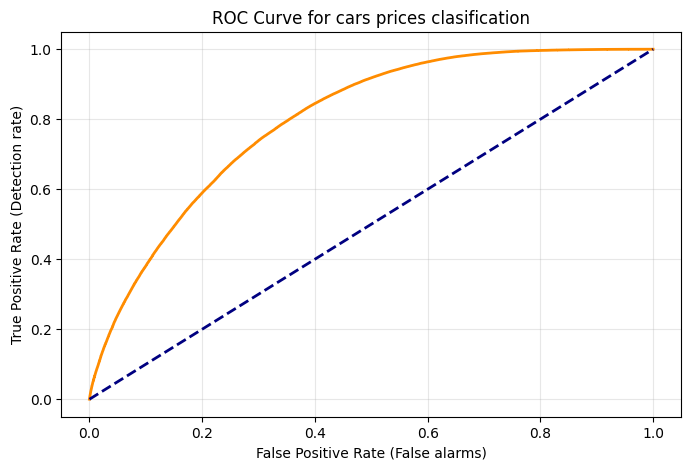

Area under the curve (AUC): 0.7975
Statistical the best treshold is: 0.2599


In [ ]:
# ROC and AUC Curve

y_probs = logit_model.predict(X_log)

fpr, tpr, thresholds = roc_curve(y_log, y_probs)
auc_value = roc_auc_score(y_log, y_probs)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {auc_value:.2f})")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--') # Line of random predict
plt.xlabel("False Positive Rate (False alarms)")
plt.ylabel("True Positive Rate (Detection rate)")
plt.title("ROC Curve for cars prices clasification")
plt.grid(alpha=0.3)
plt.show()

print(f"Area under the curve (AUC): {auc_value:.4f}")

"""
Y-axis (True Positive Rate / Recall): How many expensive cars did we manage to identify?
X-axis (False Positive Rate / 1 - Specifity): How often did we make a mistake by classifying a cheap car as expensive?
AUC (Area Under the Curve): This is the area under the curve.
0.5 -The model is guessing.
0.7-0.8 - A good model.
0.9+ - A great model.
1.0 - A perfect model (suspicious; it's probably cheating or has a data leak).
"""

optimal_idx = np.argmax(tpr - fpr)
optimal_treshold = thresholds[optimal_idx]
print(f"Statistical the best treshold is: {optimal_treshold:.4f}")


*Model is not so good at predicting if car is luxury. Also the best threshold is 0.2599, so it's very sensitive. The model is finding more luxury car (recall 0.83) but at the expense of precision (0.42) and lesser accuracy of finding normal cars (0.62).*

              precision    recall  f1-score   support

           0       0.81      0.91      0.86    126083
           1       0.57      0.35      0.44     41567

    accuracy                           0.77    167650
   macro avg       0.69      0.63      0.65    167650
weighted avg       0.75      0.77      0.75    167650



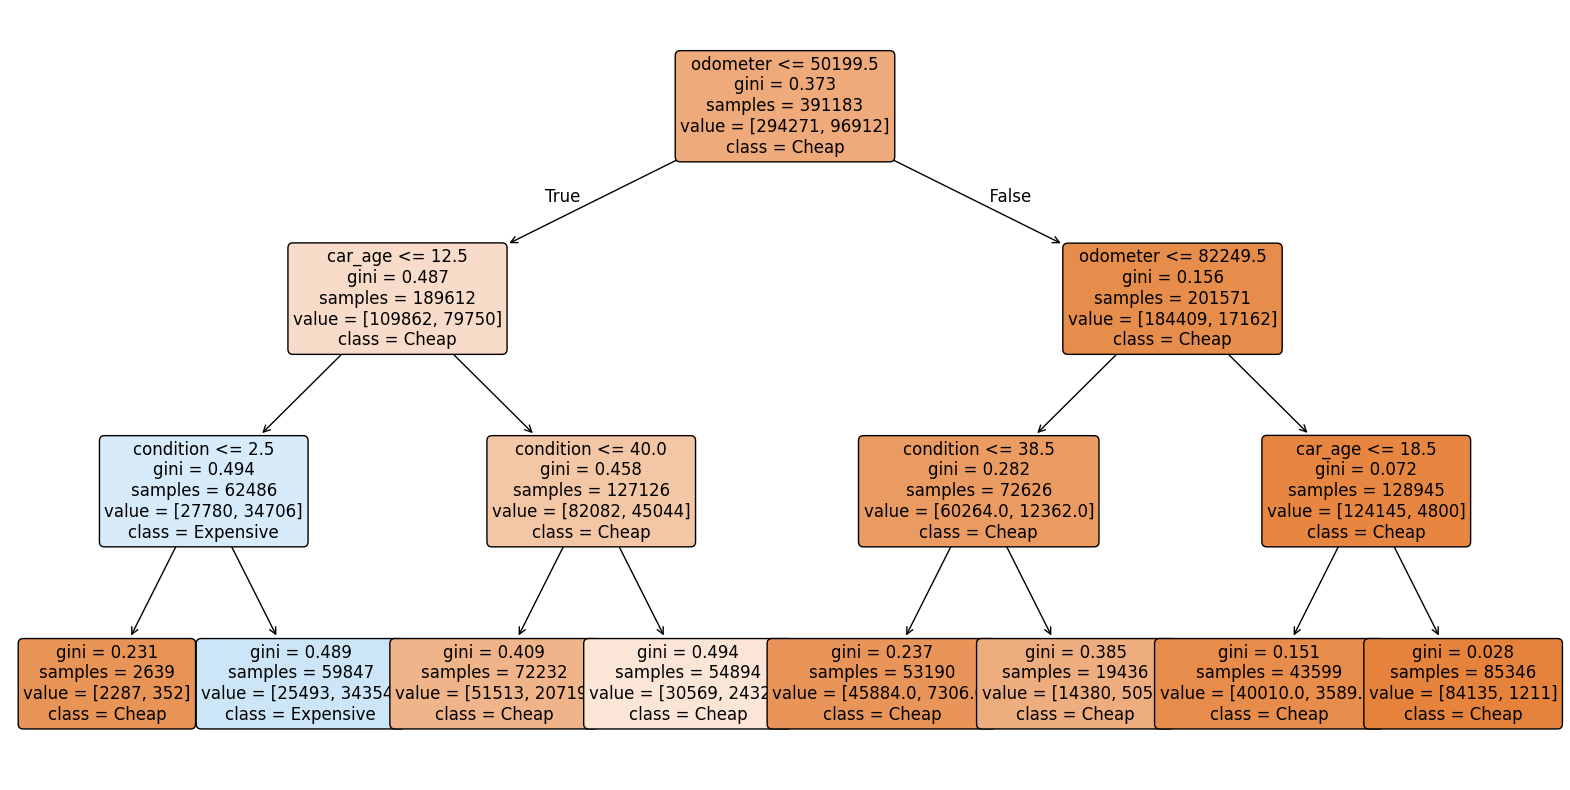

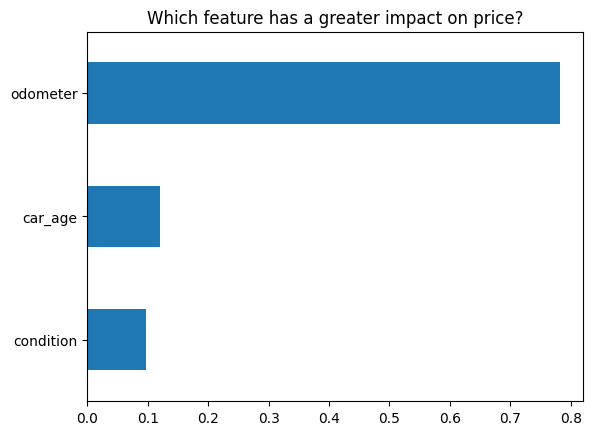

In [ ]:
# DECISION TREE
X = df[['car_age', 'condition', 'odometer']].fillna(0)
y = df['is_high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print(classification_report(y_test, y_pred_tree))

plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Cheap', 'Expensive'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.show()

# %% FEATURES IMPORTANCE
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Which feature has a greater impact on price?")
plt.show()

*In this model isn't set any threshold and it hasn't any problem to find normal car, but luxury cars is harder to find (recall 0.35 with no spectacular precision 0.57). Of course finding the luxury cars based on third quartile price is too small group to find without special features. And also this isn't a real situation and that's why in main model I will choose different approach.*